# C02 — from linear regression to neural networks

STAT41140: AI for weather and climate. Companion notebook for Class 2.

Class 1 fitted a single neuron. This notebook builds up to a real network, but stays on the
**forward pass**: given weights and biases, how does an input become a prediction? How the weights
are *learned* is Class 3.

The route:

1. dot products, and why they are the whole of a neuron
2. linear regression as a one-neuron network
3. the loss landscape, drawn so that it contains the answer
4. gradient descent, on data that has been scaled properly
5. from one feature to many: shapes, shapes, shapes
6. activations: sigmoid, tanh, ReLU, GELU
7. a 2-2-1 network by hand — including one that goes wrong
8. counting parameters
9. PyTorch and autograd
10. a problem a straight line cannot solve

**Setup.** On Linux or macOS:

```bash
python3 -m venv ~/.venvs/stat41140
source ~/.venvs/stat41140/bin/activate
python -m pip install -U pip
pip install -r requirements_ECMWF.txt
```

On Windows, either install WSL2 (Ubuntu) and use exactly the commands above, or in PowerShell:

```powershell
py -m venv $HOME\.venvs\stat41140
$HOME\.venvs\stat41140\Scripts\Activate.ps1
py -m pip install -U pip
py -m pip install -r requirements_ECMWF.txt
```

If none of that works on the day, open the notebook in Google Colab and run
`!pip install -r requirements_ECMWF.txt` in the first cell. Do not lose a week to environment
setup — come and find me instead.

Then select the interpreter in `~/.venvs/stat41140` before running anything below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (6.5, 4.5),
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

FIGS = Path("figs_c02")
FIGS.mkdir(exist_ok=True)
np.set_printoptions(precision=4, suppress=True)


def show(name, a):
    '''Print an array with its shape. Checking shapes is the habit this class is about.'''
    print(f"{name:<28} shape {str(a.shape):<8} {np.round(a, 4)}")

## 1. The data, and the dot product

The same five points as Class 1: `X` is the temperature now, `y` the temperature six hours later.
Using the identical data means you can put the two notebooks side by side.

In [2]:
np.random.seed(100)                 # same seed, same data as Class 1
X = 15 + np.random.rand(5)          # temperature now, degC
y = X + np.random.rand(5) * 0.3     # temperature in 6 h, degC

show("X (temperature now)", X)
show("y (temperature +6 h)", y)

X (temperature now)          shape (5,)     [15.5434 15.2784 15.4245 15.8448 15.0047]
y (temperature +6 h)         shape (5,)     [15.5799 15.4796 15.6723 15.8858 15.1772]


### The dot product

A neuron does exactly two things: a **dot product**, then an **addition**. Everything else in this
module is that pair, repeated.

$$a \cdot b = \sum_i a_i b_i$$

Two things to hold on to. First, the output is always a single number, whatever the length of the
inputs. Second, it is large when the two vectors are *both large* and *point the same way* — the
"similarity" reading only holds once you divide out the lengths (that is cosine similarity, and it
is what attention uses in the transformers lecture).

In [3]:
x = np.array([2.0, -3.0, 0.5])      # a toy 3-d input
w = np.array([0.1,  0.2, 0.3])      # weights, one per input
b = 0.05                            # a single bias

z = x @ w + b                       # '@' is matrix/vector multiplication in numpy
print(f"x . w = {x @ w:.4f},  plus bias  =>  z = {z:.4f}")

# Same number, three ways, to make the point that the dot product is nothing exotic:
print("by hand      :", 2.0*0.1 + (-3.0)*0.2 + 0.5*0.3)
print("np.dot       :", np.dot(x, w))
print("sum of terms :", np.sum(x * w))

x . w = -0.2500,  plus bias  =>  z = -0.2000
by hand      : -0.2500000000000001
np.dot       : -0.25
sum of terms : -0.2500000000000001


Compare magnitude with direction — the two vectors below have the same *direction* relative to `a`
but very different lengths, and only the normalised version says they are equally similar.

In [4]:
a  = np.array([1.0, 1.0])
b1 = np.array([1.0, 1.0])
b2 = np.array([5.0, 5.0])

for name, v in [("b1 = [1, 1]", b1), ("b2 = [5, 5]", b2)]:
    cos = (a @ v) / (np.linalg.norm(a) * np.linalg.norm(v))
    print(f"{name}:  dot = {a @ v:5.1f}   cosine similarity = {cos:.3f}")

b1 = [1, 1]:  dot =   2.0   cosine similarity = 1.000
b2 = [5, 5]:  dot =  10.0   cosine similarity = 1.000


## 2. Linear regression as a single neuron

$$\hat{y} = w x + b$$

A neuron with an identity activation. Let us try a few candidate parameter pairs — one bad, one
plausible, one good — and see how the error behaves.

In [5]:
def predict_lr_1d(X, w, b):
    '''Forward pass for one-feature linear regression.'''
    return w * X + b

def rmse(y_true, y_pred):
    '''Root mean squared error. Same units as y, so degC here.'''
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


for w_c, b_c in [(1.0, 1.0), (0.9, 2.0), (0.8, 3.18)]:
    print(f"w = {w_c:<4} b = {b_c:<4}  ->  RMSE = {rmse(y, predict_lr_1d(X, w_c, b_c)):.4f} degC")

w = 1.0  b = 1.0   ->  RMSE = 0.8645 degC
w = 0.9  b = 2.0   ->  RMSE = 0.3262 degC
w = 0.8  b = 3.18  ->  RMSE = 0.0792 degC


All three candidates are *plausible* — the error improves steadily rather than jumping from absurd
to good. Comparing a decent fit against a nonsense one (say $w=0$, $b=0.5$, which predicts half a
degree every day and scores an RMSE of about 15) tells you nothing you did not already know.

Notice also how far $b$ has to move to keep up with a small change in $w$: from $(1.0, 1.0)$ to
$(0.8, 3.18)$, the weight moves by 0.2 and the bias by more than 2. That is the canyon from Class 1
showing up again, and section 4 is where we look at it properly.

## 3. Seeing the candidates

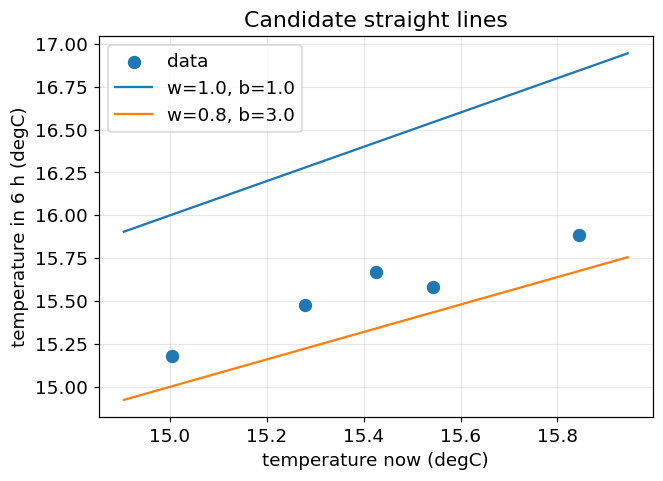

In [6]:
fig, ax = plt.subplots()
ax.scatter(X, y, s=60, zorder=3, label="data")
xgrid = np.linspace(X.min() - 0.1, X.max() + 0.1, 100)
for w_c, b_c in [(1.0, 1.0), (0.8, 3.0)]:
    ax.plot(xgrid, w_c * xgrid + b_c, label=f"w={w_c}, b={b_c}")
ax.set_xlabel("temperature now (degC)")
ax.set_ylabel("temperature in 6 h (degC)")
ax.set_title("Candidate straight lines")
ax.legend()
fig.savefig(FIGS / "c02_fig01_candidates.png")
plt.show()

## 4. The loss landscape — drawn so that it contains the answer

We can compute the exact best fit, which tells us where the minimum of the landscape actually is.
Then we can be sure the picture we draw contains it — a contour plot that misses the minimum is
worse than no contour plot at all.

In [7]:
def least_squares(X, y):
    '''Exact minimiser of the squared error, for a straight line.'''
    D = np.column_stack([np.ones_like(X), X])
    b_hat, w_hat = np.linalg.lstsq(D, y, rcond=None)[0]
    return w_hat, b_hat

w_exact, b_exact = least_squares(X, y)
print(f"exact answer on the RAW data:  w = {w_exact:.4f},  b = {b_exact:.4f}")
print(f"lowest possible RMSE: {rmse(y, predict_lr_1d(X, w_exact, b_exact)):.4f} degC")

exact answer on the RAW data:  w = 0.8029,  b = 3.1791
lowest possible RMSE: 0.0661 degC


The bias is over 3, not somewhere near zero — because every temperature sits close to 15.4 °C, so
the line has to be extrapolated a long way back to reach the vertical axis. This is the same
awkwardness Class 1 ran into, and the same fix applies: work in **anomalies** about a 15 °C
reference.

In [8]:
REF = 15.0
Xa, ya = X - REF, y - REF                 # anomalies, degC
w_exact_a, b_exact_a = least_squares(Xa, ya)
print(f"exact answer on ANOMALIES:  w = {w_exact_a:.4f},  b = {b_exact_a:.4f}")


def conditioning(X):
    '''Curvature of the squared-error surface: eigenvalues, condition number, stable lr.'''
    D = np.column_stack([np.ones_like(X), X])
    ev = np.linalg.eigvalsh(2 * D.T @ D / len(X))
    return ev[-1] / ev[0], 2 / ev[-1]

for label, xx in [("raw", X), ("anomalies", Xa)]:
    cond, lr_max = conditioning(xx)
    print(f"{label:<10} condition number {cond:12,.1f}   largest stable learning rate {lr_max:.4f}")

exact answer on ANOMALIES:  w = 0.8029,  b = 0.2224
raw        condition number    734,659.6   largest stable learning rate 0.0042
anomalies  condition number         18.2   largest stable learning rate 0.8418


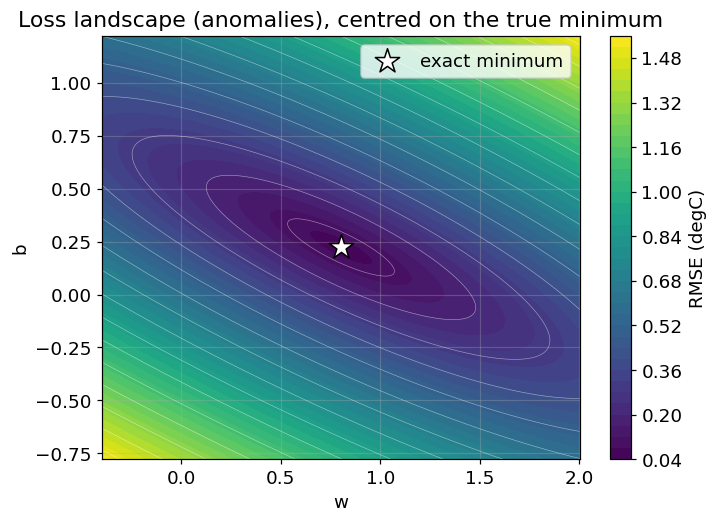

In [9]:
w_grid = np.linspace(w_exact_a - 1.2, w_exact_a + 1.2, 200)
b_grid = np.linspace(b_exact_a - 1.0, b_exact_a + 1.0, 200)
W, B = np.meshgrid(w_grid, b_grid)
L = np.array([[rmse(ya, predict_lr_1d(Xa, wv, bv)) for wv in w_grid] for bv in b_grid])

fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(W, B, L, levels=40, cmap="viridis")
fig.colorbar(cf, ax=ax, label="RMSE (degC)")
ax.contour(W, B, L, levels=15, colors="white", linewidths=0.4, alpha=0.5)
ax.scatter([w_exact_a], [b_exact_a], marker="*", s=280, color="white",
           edgecolor="black", zorder=5, label="exact minimum")
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_title("Loss landscape (anomalies), centred on the true minimum")
ax.legend()
fig.savefig(FIGS / "c02_fig02_landscape.png")
plt.show()

## 5. Gradient descent, done on the scaled data

Gradients of the mean squared error:

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_i (\hat{y}_i - y_i)\,x_i,
\qquad
\frac{\partial L}{\partial b} = \frac{2}{n}\sum_i (\hat{y}_i - y_i)$$

We minimise the MSE and report the RMSE, because RMSE is in degrees.

In [10]:
def compute_gradients_1d(X, y, w, b):
    '''Gradients of the MEAN squared error with respect to w and b.'''
    residual = (w * X + b) - y
    return float(2 * np.mean(residual * X)), float(2 * np.mean(residual))


def gradient_descent_1d(X, y, w0=0.0, b0=0.0, lr=0.5, epochs=100, verbose_every=None):
    w, b, losses = float(w0), float(b0), []
    for epoch in range(epochs):
        dw, db = compute_gradients_1d(X, y, w, b)
        w -= lr * dw
        b -= lr * db
        losses.append(rmse(y, w * X + b))
        if verbose_every and epoch % verbose_every == 0:
            print(f"epoch {epoch:4d} | RMSE {losses[-1]:.6f} | w {w:.4f} | b {b:.4f}")
    return w, b, losses


w_hat, b_hat, loss_hist = gradient_descent_1d(Xa, ya, lr=0.5, epochs=100, verbose_every=20)
print()
print(f"gradient descent: w = {w_hat:.4f},  b = {b_hat:.4f}")
print(f"exact answer    : w = {w_exact_a:.4f},  b = {b_exact_a:.4f}")

epoch    0 | RMSE 0.199320 | w 0.2966 | b 0.5590
epoch   20 | RMSE 0.077099 | w 0.6613 | b 0.2859
epoch   40 | RMSE 0.066902 | w 0.7662 | b 0.2389
epoch   60 | RMSE 0.066163 | w 0.7934 | b 0.2267
epoch   80 | RMSE 0.066113 | w 0.8004 | b 0.2235

gradient descent: w = 0.8022,  b = 0.2227
exact answer    : w = 0.8029,  b = 0.2224


Agreement to three decimal places in a hundred epochs. **Try the same run on the raw `X` and `y`
with the same learning rate** — it diverges immediately, and even at the largest stable learning
rate it needs of the order of a million epochs. That is the point Class 1 made, and it is the
reason we scale.

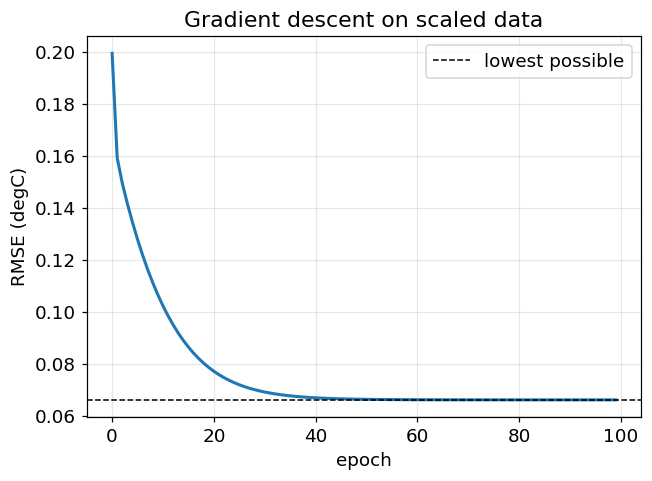

In [11]:
fig, ax = plt.subplots()
ax.plot(loss_hist, lw=2)
ax.axhline(rmse(ya, predict_lr_1d(Xa, w_exact_a, b_exact_a)), color="black", ls="--", lw=1,
           label="lowest possible")
ax.set_xlabel("epoch")
ax.set_ylabel("RMSE (degC)")
ax.set_title("Gradient descent on scaled data")
ax.legend()
fig.savefig(FIGS / "c02_fig03_gd.png")
plt.show()

## 6. From one feature to many: shapes

Nothing about the neuron changes; the weight becomes a vector and the dot product does the summing.
This section is about **shapes**, not about fitting — the data below are generated from an exact
linear rule with no noise, so there is nothing to learn. Read it for the dimensions.

In [12]:
humidity = np.array([65, 70, 68, 72, 60], float)      # yesterday's humidity, %
X2 = np.column_stack([X, humidity])                    # (5, 2)

w_true = np.array([0.9, -0.02])                        # per degC, per %
b_true = 1.5

y2 = X2 @ w_true + b_true                              # (5,) — one output per day

show("X2 (5 days, 2 features)", X2)
show("w_true", w_true)
show("y2 = X2 @ w_true + b_true", y2)

print(f"\nshapes:  X2 {X2.shape} @ w_true {w_true.shape} -> {(X2 @ w_true).shape}, "
      f"plus a scalar bias broadcast to every row")

X2 (5 days, 2 features)      shape (5, 2)   [[15.5434 65.    ]
 [15.2784 70.    ]
 [15.4245 68.    ]
 [15.8448 72.    ]
 [15.0047 60.    ]]
w_true                       shape (2,)     [ 0.9  -0.02]
y2 = X2 @ w_true + b_true    shape (5,)     [14.1891 13.8505 14.0221 14.3203 13.8042]

shapes:  X2 (5, 2) @ w_true (2,) -> (5,), plus a scalar bias broadcast to every row


### Multiple outputs: the weights become a matrix

To predict several things at once (temperature *and* humidity *and* wind speed) we need one row of
weights per output:

$$\hat{y} = W x + b, \qquad W \in \mathbb{R}^{m \times n},\; x \in \mathbb{R}^{n},\;
b,\hat{y} \in \mathbb{R}^{m}$$

This is the worked example from the slides. Predict the shape of the answer before you run it.

In [13]:
W = np.array([[ 3.0,  2.0],
              [-1.0,  0.0],
              [-1.0,  1.0]])          # (3, 2): 3 outputs, 2 inputs
b_vec = np.array([2.0, 3.0, 0.0])     # (3,) — one bias per output
x_in = np.array([1.0, 1.0])           # (2,)

y_hat = W @ x_in + b_vec
show("W", W)
show("x", x_in)
show("b", b_vec)
show("y_hat = W x + b", y_hat)

W                            shape (3, 2)   [[ 3.  2.]
 [-1.  0.]
 [-1.  1.]]
x                            shape (2,)     [1. 1.]
b                            shape (3,)     [2. 3. 0.]
y_hat = W x + b              shape (3,)     [7. 2. 0.]


## 7. Classification: the forward pass only

Swap the identity activation for a sigmoid and the output becomes a probability. We are **not**
training here — this is a forward pass at randomly chosen weights, so the loss below is just the
starting point Class 3 will improve on.

In [14]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_prob, eps=1e-15):
    '''Negative log-likelihood of a Bernoulli. Clipped so we never take log(0).'''
    y_prob = np.clip(y_prob, eps, 1.0 - eps)
    return float(-np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob)))


rng = np.random.default_rng(0)
N = 200
x1, x2 = rng.normal(size=N), rng.normal(size=N)
Xb = np.column_stack([x1, x2])

# A boundary NO straight line can draw: 'hot' is a disc around the origin.
ybin = (x1**2 + x2**2 < 1.2).astype(float)
print(f"class balance: {ybin.mean():.1%} in class 1")

w_log = rng.normal(size=2)
p = sigmoid(Xb @ w_log + 0.0)
print(f"forward pass at random weights -> BCE = {binary_cross_entropy(ybin, p):.4f}")
print("(chance level for this class balance is about "
      f"{binary_cross_entropy(ybin, np.full(N, ybin.mean())):.4f})")

class balance: 43.5% in class 1
forward pass at random weights -> BCE = 0.7375
(chance level for this class balance is about 0.6847)


## 8. Activation functions

Four of them, including the two the slides name. GELU is what most modern transformers use — AIFS
included — so it is worth seeing next to ReLU rather than only hearing about it.

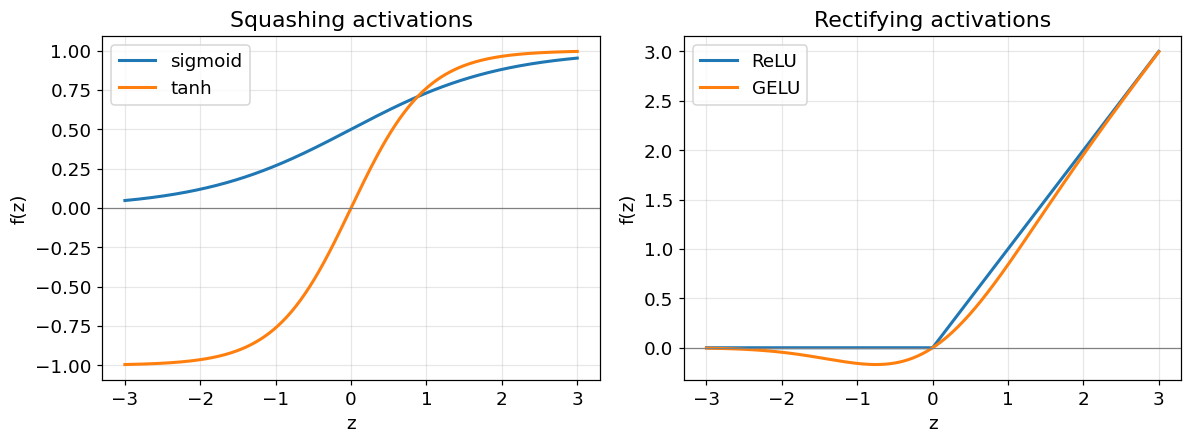

sigmoid never actually reaches 0 or 1:
  sigmoid(-10) = 0.00004540   sigmoid(10) = 0.99995460
ReLU has no derivative at exactly 0 — the kink. By convention libraries return 0 there.


In [15]:
from math import erf

def relu(z):
    return np.maximum(0.0, z)

def tanh(z):
    return np.tanh(z)

def gelu(z):
    '''Exact GELU: x * Phi(x), where Phi is the standard normal CDF.'''
    return z * 0.5 * (1.0 + np.vectorize(erf)(z / np.sqrt(2.0)))


zz = np.linspace(-3, 3, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(zz, sigmoid(zz), lw=2, label="sigmoid")
axes[0].plot(zz, tanh(zz), lw=2, label="tanh")
axes[0].axhline(0, color="grey", lw=0.8)
axes[0].set_title("Squashing activations")
axes[0].set_xlabel("z"); axes[0].set_ylabel("f(z)"); axes[0].legend()

axes[1].plot(zz, relu(zz), lw=2, label="ReLU")
axes[1].plot(zz, gelu(zz), lw=2, label="GELU")
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_title("Rectifying activations")
axes[1].set_xlabel("z"); axes[1].set_ylabel("f(z)"); axes[1].legend()

fig.tight_layout()
fig.savefig(FIGS / "c02_fig04_activations.png")
plt.show()

print("sigmoid never actually reaches 0 or 1:")
print("  sigmoid(-10) =", f"{sigmoid(-10.0):.8f}", "  sigmoid(10) =", f"{sigmoid(10.0):.8f}")
print("ReLU has no derivative at exactly 0 — the kink. By convention libraries return 0 there.")

## 9. A 2-2-1 network by hand

Two inputs → two hidden units with ReLU → one output with an identity activation.

```
W1: (2, 2)   b1: (2,)      W2: (2, 1)   b2: (1,)
```

In [16]:
W1 = np.array([[ 0.5, -0.4],
               [ 1.1,  0.2]])
b1 = np.array([0.0, -0.1])
W2 = np.array([[ 0.7],
               [-1.0]])
b2 = np.array([0.05])


def forward_2_2_1(x, W1, b1, W2, b2, verbose=False):
    '''One forward pass, printing every intermediate quantity if asked.'''
    h_pre = x @ W1 + b1        # pre-activation of the hidden layer
    h = relu(h_pre)            # hidden activations
    y_hat = h @ W2 + b2        # output layer, identity activation
    if verbose:
        show("  input x", x)
        show("  h_pre = x W1 + b1", h_pre)
        show("  h = ReLU(h_pre)", h)
        show("  y_hat = h W2 + b2", y_hat)
    return float(y_hat.item())


print("Example A")
yA = forward_2_2_1(np.array([0.0, 2.0]), W1, b1, W2, b2, verbose=True)
print(f"  => y_hat = {yA:.4f}\n")

Example A
  input x                    shape (2,)     [0. 2.]
  h_pre = x W1 + b1          shape (2,)     [2.2 0.3]
  h = ReLU(h_pre)            shape (2,)     [2.2 0.3]
  y_hat = h W2 + b2          shape (1,)     [1.29]
  => y_hat = 1.2900



Every quantity in Example A is doing something: both hidden units are active, both weights in `W2`
contribute, and the answer depends on all nine parameters.

Now the same network on a different input.

In [17]:
print("Example B")
yB = forward_2_2_1(np.array([0.3, -1.2]), W1, b1, W2, b2, verbose=True)
print(f"  => y_hat = {yB:.4f}")
print(f"  (b2 alone is {b2[0]})")

Example B
  input x                    shape (2,)     [ 0.3 -1.2]
  h_pre = x W1 + b1          shape (2,)     [-1.17 -0.46]
  h = ReLU(h_pre)            shape (2,)     [0. 0.]
  y_hat = h W2 + b2          shape (1,)     [0.05]
  => y_hat = 0.0500
  (b2 alone is 0.05)


> **Question for the room:** why did the answer come out as exactly the output bias?

Both hidden pre-activations were negative, so ReLU set both to zero, and the whole network
collapsed to `y_hat = b2`. For this input the network has learned nothing and *can* learn nothing:
the gradient flowing back through a unit whose output is zero is itself zero. This is the **dead
ReLU** problem, and it is one reason GELU — which has a small negative tail rather than a hard
zero — is preferred in deep models.

Two habits follow. Print your pre-activations when a network will not train. And scale your inputs,
so that pre-activations start near zero rather than far out in the flat region.

In [18]:
# EXERCISE: set b1 and b2 to zero and re-run Example A. What changes, and why?
yA_nobias = forward_2_2_1(np.array([0.0, 2.0]), W1, np.zeros(2), W2, np.zeros(1))
print(f"Example A with all biases zero: y_hat = {yA_nobias:.4f}  (was {yA:.4f})")

Example A with all biases zero: y_hat = 1.1400  (was 1.2900)


## 10. Counting parameters

Every line in the network diagram is one weight; every neuron that is not an input also has one
bias. For a network with layer sizes $n_0, n_1, \dots, n_L$:

$$\text{weights} = \sum_{\ell} n_{\ell-1} n_{\ell}, \qquad
\text{biases} = \sum_{\ell} n_{\ell}$$

In [19]:
def count_parameters(sizes):
    '''sizes = [inputs, hidden1, hidden2, ..., outputs].'''
    weights = sum(a * b for a, b in zip(sizes[:-1], sizes[1:]))
    biases = sum(sizes[1:])
    return weights, biases


for sizes in [[2, 2, 1], [2, 2, 2], [4, 3, 3, 1]]:
    w_n, b_n = count_parameters(sizes)
    print(f"{str(sizes):<16} weights {w_n:>3}   biases {b_n:>3}   total {w_n + b_n:>3}")

[2, 2, 1]        weights   6   biases   3   total   9
[2, 2, 2]        weights   8   biases   4   total  12
[4, 3, 3, 1]     weights  24   biases   7   total  31


The last line is the poll question from the slides. Note the distinction the poll turns on: **24
weights**, and 31 parameters once the biases are counted. When someone quotes a model size — AIFS,
GraphCast — they mean the total.

## 11. PyTorch: the same thing, with autograd

Everything so far was written out by hand so that nothing is mysterious. PyTorch does the same
arithmetic, and computes the gradients for you.

In [20]:
import torch
torch.manual_seed(42)

# Scaled inputs, for the reason established in section 4.
X_t = torch.tensor(Xa, dtype=torch.float32).unsqueeze(1)     # (5, 1)
y_t = torch.tensor(ya, dtype=torch.float32).unsqueeze(1)     # (5, 1)

model_lr = torch.nn.Linear(in_features=1, out_features=1, bias=True)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model_lr.parameters(), lr=0.5)

losses_torch = []
for epoch in range(100):
    optimizer.zero_grad()
    loss = criterion(model_lr(X_t), y_t)
    loss.backward()          # autograd fills in every d(loss)/d(parameter)
    optimizer.step()
    losses_torch.append(loss.item() ** 0.5)
    if epoch % 20 == 0:
        print(f"epoch {epoch:3d} | RMSE {losses_torch[-1]:.6f} | "
              f"w {model_lr.weight.item():.4f} | b {model_lr.bias.item():.4f}")

print()
print(f"PyTorch : w = {model_lr.weight.item():.4f},  b = {model_lr.bias.item():.4f}")
print(f"by hand : w = {w_hat:.4f},  b = {b_hat:.4f}")
print(f"exact   : w = {w_exact_a:.4f},  b = {b_exact_a:.4f}")

epoch   0 | RMSE 0.595293 | w 0.5196 | b 0.2385
epoch  20 | RMSE 0.068721 | w 0.7403 | b 0.2505
epoch  40 | RMSE 0.066288 | w 0.7867 | b 0.2297
epoch  60 | RMSE 0.066121 | w 0.7987 | b 0.2243
epoch  80 | RMSE 0.066110 | w 0.8018 | b 0.2229

PyTorch : w = 0.8026,  b = 0.2226
by hand : w = 0.8022,  b = 0.2227
exact   : w = 0.8029,  b = 0.2224


Three routes, one answer. That is the check worth doing whenever you move a model into a framework.

## 12. Where a hidden layer actually earns its keep

The classification data in section 7 has a **circular** boundary. No straight line can separate a
disc from the ring around it, so logistic regression — a single neuron — must fail, and a network
with one hidden layer should succeed. This is the experiment that shows what the extra layer buys
you; a linearly separable problem would not.

We hold out a test set, because training accuracy on its own tells you nothing.

In [21]:
n_train = 140
Xb_train, Xb_test = Xb[:n_train], Xb[n_train:]
yb_train, yb_test = ybin[:n_train], ybin[n_train:]

Xtr = torch.tensor(Xb_train, dtype=torch.float32)
ytr = torch.tensor(yb_train, dtype=torch.float32).unsqueeze(1)
Xte = torch.tensor(Xb_test, dtype=torch.float32)
yte = torch.tensor(yb_test, dtype=torch.float32).unsqueeze(1)


def fit(model, epochs=400, lr=0.05):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossfn = torch.nn.BCEWithLogitsLoss()      # sigmoid + BCE, done stably
    hist = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = lossfn(model(Xtr), ytr)
        loss.backward()
        opt.step()
        hist.append(loss.item())
    return hist


def accuracy(model, Xd, yd):
    with torch.no_grad():
        return float(((torch.sigmoid(model(Xd)) > 0.5).float() == yd).float().mean())


torch.manual_seed(0)
logreg = torch.nn.Linear(2, 1)                       # one neuron: logistic regression
hist_lin = fit(logreg)

torch.manual_seed(0)
mlp = torch.nn.Sequential(                            # 2 -> 8 (ReLU) -> 1
    torch.nn.Linear(2, 8),
    torch.nn.ReLU(),
    torch.nn.Linear(8, 1),
)
hist_mlp = fit(mlp)

majority = max(yb_test.mean(), 1 - yb_test.mean())

print(f"{'':26s} {'train':>8s} {'test':>8s}")
print(f"{'always guess the majority':26s} {'':>8s} {majority:8.2%}")
print(f"{'logistic regression':26s} {accuracy(logreg, Xtr, ytr):8.2%} {accuracy(logreg, Xte, yte):8.2%}")
print(f"{'MLP with 1 hidden layer':26s} {accuracy(mlp, Xtr, ytr):8.2%} {accuracy(mlp, Xte, yte):8.2%}")
print()
print("parameters:", sum(p.numel() for p in logreg.parameters()), "vs",
      sum(p.numel() for p in mlp.parameters()))

                              train     test
always guess the majority             56.67%
logistic regression          47.86%   35.00%
MLP with 1 hidden layer     100.00%   96.67%

parameters: 3 vs 33


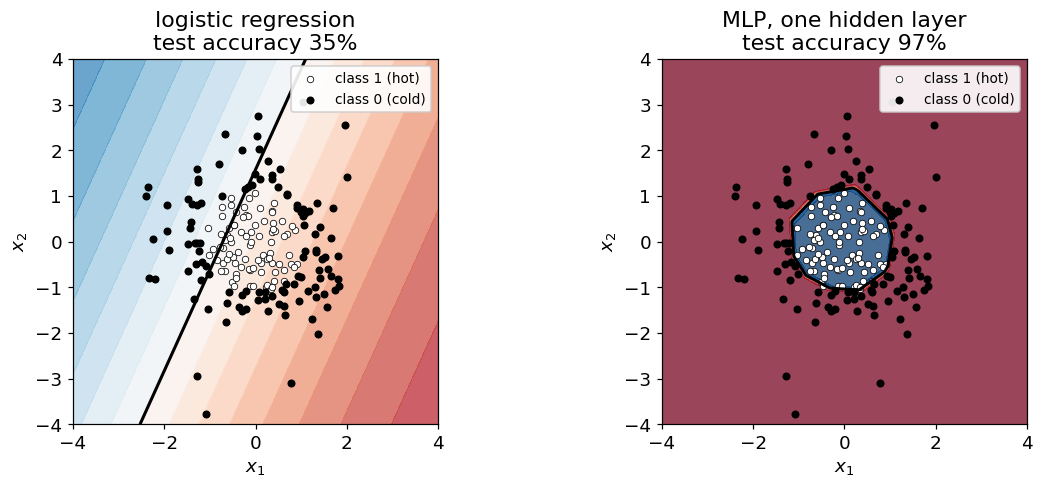

In [22]:
gx, gy = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4, 4, 300))
grid = torch.tensor(np.column_stack([gx.ravel(), gy.ravel()]), dtype=torch.float32)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, model, name, hist in [(axes[0], logreg, "logistic regression", hist_lin),
                              (axes[1], mlp, "MLP, one hidden layer", hist_mlp)]:
    with torch.no_grad():
        prob = torch.sigmoid(model(grid)).numpy().reshape(gx.shape)
    ax.contourf(gx, gy, prob, levels=np.linspace(0, 1, 21), cmap="RdBu", alpha=0.75)
    ax.contour(gx, gy, prob, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(Xb[ybin == 1, 0], Xb[ybin == 1, 1], s=18, c="white", edgecolor="black", lw=0.5,
               label="class 1 (hot)")
    ax.scatter(Xb[ybin == 0, 0], Xb[ybin == 0, 1], s=18, c="black", label="class 0 (cold)")
    ax.set_title(f"{name}\ntest accuracy {accuracy(model, Xte, yte):.0%}")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect("equal"); ax.grid(False)
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

fig.tight_layout()
fig.savefig(FIGS / "c02_fig05_boundaries.png")
plt.show()

The left panel is the best a straight line can do — in fact it scores *below* the majority-class
baseline, which is what "this model class cannot represent the answer" looks like in practice. The right panel bends. That is the entire argument for hidden layers and
non-linear activations, in one figure — and it is why the poll about stacking ten layers with no
activation has the answer it does: without a non-linearity, the right panel would look like the
left one no matter how many layers you added.

## 13. Sanity checks and common pitfalls

1. **Check shapes at every layer.** Most bugs are shape bugs.
2. **Do not forget the biases.**
3. **Match the activation to the task**: identity for regression, sigmoid (or logits) for binary
   classification.
4. **Scale your inputs.** Sections 4 and 5 above; also the reason Example B went dead.
5. **Print pre-activations when a network will not train** — you may be looking at dead units.
6. **Learning rate matters**: too large diverges, too small crawls.
7. **Hold out a test set.** Training accuracy of 100% is not a result.
8. For weather and climate, split **chronologically**, never at random.

## 14. Things to try

1. Re-run section 5 on the raw `X`, `y` with `lr=0.5`. How many epochs before it overflows?
2. In section 9, find an input for which exactly *one* hidden unit is alive.
3. Replace `torch.nn.ReLU()` in section 12 with `torch.nn.Tanh()` and then with
   `torch.nn.Identity()`. Which one loses the circle, and why?
4. Shrink the hidden layer in section 12 from 8 units to 2. How much accuracy do you lose?
5. Use `count_parameters` to work out how many parameters a 4-64-64-4 network has. Compare with
   AIFS, which has of the order of $10^8$.